# Motor validation — manuscript results

Pools the complete camera runs under `responses/` and writes the tables, figure
and LaTeX the paper uses into `results/<SELECTION>/`, in the same layout as the
other analysis notebooks:

```
results/<SELECTION>/
    csv/response/     branch_table.csv           +Δ / −Δ per amplitude, mean ± SD, error vs nominal
    csv/hysteresis/   hysteresis_table.csv       return-to-zero offset by approach direction
    csv/resolution/   resolution_table.csv       tick → deg → mm at the spool
    csv/summary/      motor_validation_table.csv one merged table, one row per amplitude
                      motor_validation_table.tex the same table as a booktabs tabular
                      calibration.json           gain, R², repeatability, quantisation step
    figures/review/   motor_validation_review_figure.{png,svg}  +  panel_A / B / C on their own
```

All computation lives in `motor_validation.py`; this notebook only configures,
runs and displays.

## 1. Configuration

In [1]:

SELECTION = "all_runs"          # name of the results/<SELECTION>/ folder
SPOOL_RADIUS_MM = 4.0           # for the cable-displacement column
RUN_DIRS = None                 # None = every complete camera run under responses/;
                                # or a list of Path(...) to pool a specific subset

## 2. Run

In [2]:
import motor_validation as mv

r = mv.run(selection=SELECTION, spool_radius_mm=SPOOL_RADIUS_MM, run_dirs=RUN_DIRS)
print(f"pooled {len(r['runs'])} runs:")
for p in r["runs"]:
    print("  ", p.name)
print()
print("results written to:", r["results_dir"])

pooled 3 runs:
   motor_response_2026_04_28_14_17_48
   motor_response_2026_04_28_14_34_58
   motor_response_2026_04_28_15_02_26

results written to: C:\Users\user\BIO MEDICAL ROBOTICS Dropbox\Elisheva Shiri Decktor\BGU\Codes\Parallel_Heptics\validetion\Servomotor\results\all_runs


## 3. Calibration summary

In [3]:
import json

print(json.dumps(r["calibration"], indent=2))

{
  "runs": [
    "motor_response_2026_04_28_14_17_48",
    "motor_response_2026_04_28_14_34_58",
    "motor_response_2026_04_28_15_02_26"
  ],
  "fit_range_ticks": [
    25,
    500
  ],
  "gain_deg_per_tick": 0.09200951242750122,
  "fit_r2": 0.9997732464283111,
  "assumed_deg_per_tick": 0.09,
  "pooled_repeatability_sd_deg": 0.6048403753852528,
  "max_abs_hysteresis_deg": 0.7853484998677627,
  "pwm_step_ticks": 5.405405405405405,
  "pwm_step_deg": 0.4973487158243309,
  "pwm_step_mm": 0.03472149048680079,
  "spool_radius_mm": 4.0
}


## 4. Merged table (one row per amplitude)

`pos/neg` = trial-local rotation for +Δ / −Δ commands (mean ± SD, n = 18 each);
`error_pct` = |mean| vs the nominal 0.09°/tick scale; `hysteresis_deg` = angle at
commanded 0 arriving from +Δ minus arriving from −Δ (± SE); `cable_mm` = |mean|
converted to cable displacement at the spool.

In [4]:
r["merged"].round(3)

,delta,nominal_deg,pos_mean,pos_sd,neg_mean,neg_sd,mean_abs,error_pct,hysteresis_deg,hysteresis_se,cable_mm,n_pos,n_neg
0,5,0.45,0.034,0.228,0.049,0.201,0.041,90.831,0.028,0.098,0.003,18,18
1,10,0.90,0.080,0.259,0.005,0.244,0.042,95.287,0.144,0.134,0.003,18,18
2,25,2.25,1.586,0.826,-2.372,0.974,1.979,12.048,-0.012,0.183,0.138,18,18
3,75,6.75,6.593,0.690,-7.677,0.449,7.135,5.700,-0.785,0.242,0.498,18,18
4,125,11.25,10.797,0.614,-12.845,0.398,11.821,5.074,-0.437,0.114,0.825,18,18
5,250,22.50,22.754,0.589,-23.329,0.749,23.041,2.406,-0.638,0.112,1.609,18,18
6,500,45.00,45.307,0.425,-46.466,0.458,45.886,1.970,0.075,0.192,3.203,18,18
7,1000,90.00,86.587,0.734,-80.044,0.976,83.315,7.427,0.348,0.149,5.817,18,18


## 5. Resolution: tick → degree → mm

In [5]:
r["resolution"].round(4)

,item,ticks,linear_deg,measured_deg,linear_mm,measured_mm
0,1 command tick,1.0000,0.0920,NaN,0.0064,NaN
1,1 PWM step (quantisation floor),5.4054,0.4973,NaN,0.0347,NaN
2,5 ticks,5.0000,0.4600,0.0413,0.0321,0.0029
3,10 ticks,10.0000,0.9201,0.0424,0.0642,0.0030
4,15 ticks,15.0000,1.3801,NaN,0.0964,NaN
5,25 ticks,25.0000,2.3002,1.9789,0.1606,0.1382
6,full 1000-tick command,1000.0000,92.0095,83.3154,6.4235,5.8165


## 6. Figure

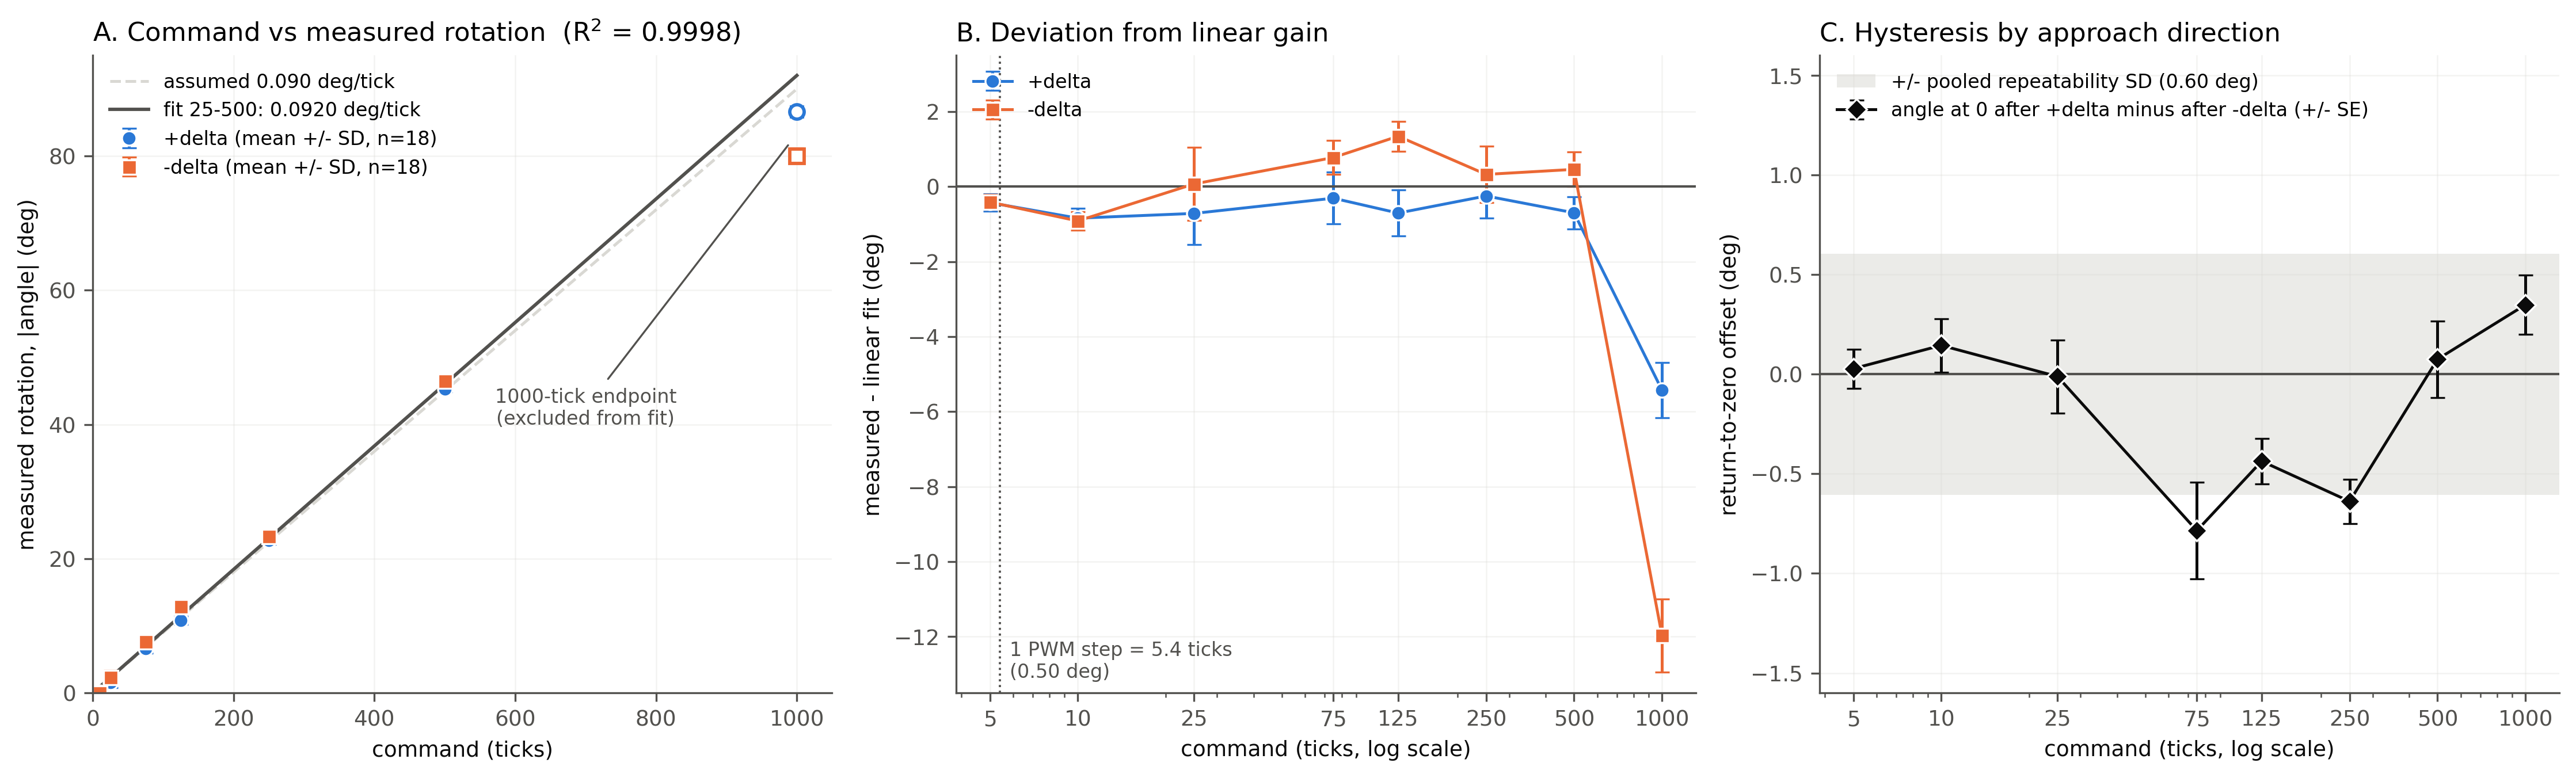

In [6]:
from IPython.display import Image, display

display(Image(filename=str(r["figures"]["motor_validation_review_figure"][0]), width=1400))

## 7. LaTeX table (`\usepackage{booktabs}`)

In [7]:
print(r["latex"])

\begin{table}[!h]
\centering
\fontsize{7.5}{9}\selectfont
\caption{Motor validation: measured spool rotation per command amplitude, pooled over three runs ($n = 18$ per direction). Values are mean\,$\pm$\,SD; hysteresis is mean\,$\pm$\,SE.}\label{tab:motor_validation}
\setlength{\tabcolsep}{2.5pt}
\renewcommand{\arraystretch}{1.05}
\begin{tabular}{@{}r r r@{\,$\pm$\,}l r@{\,$\pm$\,}l r r r@{\,$\pm$\,}l r@{}}
\toprule
$\Delta$ & Nom. & \multicolumn{2}{c}{$+\Delta$} & \multicolumn{2}{c}{$-\Delta$} & $|\bar\theta|$ & Error & \multicolumn{2}{c}{Hyst.} & Cable \\
(ticks) & ($^\circ$) & \multicolumn{2}{c}{($^\circ$)} & \multicolumn{2}{c}{($^\circ$)} & ($^\circ$) & (\%) & \multicolumn{2}{c}{($^\circ$)} & (mm) \\
\midrule
5 & 0.45 & 0.03 & 0.23 & 0.05 & 0.20 & 0.04 & 90.8 & +0.03 & 0.10 & 0.003 \\
10 & 0.90 & 0.08 & 0.26 & 0.01 & 0.24 & 0.04 & 95.3 & +0.14 & 0.13 & 0.003 \\
25 & 2.25 & 1.59 & 0.83 & $-$2.37 & 0.97 & 1.98 & 12.0 & $-$0.01 & 0.18 & 0.138 \\
75 & 6.75 & 6.59 & 0.69 & $-$7.68 & 0.

## Conventions

* **Gain** is fitted through the origin over 25–500 ticks; the 1000-tick endpoint sits at the
  detector's 180° line-orientation limit and is reported as a range check, not a calibration point.
* **5 and 10 ticks** produce no detectable rotation (≈0.04°, within noise). The floor is set by the
  PCA9685: the ±1000 command range spans 370 PWM steps, so one step is 5.4 ticks ≈ 0.50°.
* **Hysteresis** is the return-to-zero offset by approach direction — the quantity the drift periods
  probe. The protocol is not a monotonic sweep, so a classical hysteresis loop cannot be drawn.
* Runs taken with the full mechanism attached are **not** motor calibration (extra friction); keep
  them out of `responses/`.